# Task 2 ? Yelp Polarity Data Analysis and Preprocessing

**Member:** Anshika Goel  
**Team:** 15  
**Dataset:** `fancyzhx/yelp_polarity`

This executed notebook performs the complete data-analysis and preprocessing stage for Task 2.

The final notebook will:

- load the pinned Yelp Polarity dataset revision;
- verify the official dataset schema and split sizes;
- inspect labels, class balance, missing values, malformed text, duplicates, and review lengths;
- construct a deterministic stratified training/validation split;
- normalize and tokenize reviews;
- remove stopwords while preserving sentiment-bearing negations;
- apply Porter stemming;
- construct a vocabulary using only the training split;
- encode reviews into fixed-length sequences;
- save reproducible processed arrays and integrity manifests.

No pretrained embeddings or pretrained language models are used. All model embeddings will be learned from scratch during Task 2 training.

## Phase A

The current cells perform the raw-data audit. Preprocessing cells will be added after this phase executes successfully.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
import platform
import random
import re
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import yaml
from datasets import load_dataset
from IPython.display import display
from tqdm.auto import tqdm


search_start = Path.cwd().resolve()

repository_candidates = [
    search_start,
    *search_start.parents,
]

repo_root = next(
    candidate
    for candidate in repository_candidates
    if (
        candidate
        / "task2_sentiment"
        / "Anshika_Goel"
    ).is_dir()
)

member_root = (
    repo_root
    / "task2_sentiment"
    / "Anshika_Goel"
)
config_path = (
    member_root
    / "configs"
    / "sentiment.yaml"
)
metrics_directory = (
    member_root
    / "outputs"
    / "metrics"
)
plots_directory = (
    member_root
    / "outputs"
    / "plots"
)

metrics_directory.mkdir(parents=True, exist_ok=True)
plots_directory.mkdir(parents=True, exist_ok=True)

default_cache_directory = (
    repo_root
    / "task2_sentiment"
    / "data"
    / "hf_cache"
    / "datasets"
)
cache_directory = Path(
    os.environ.get(
        "HF_DATASETS_CACHE",
        str(default_cache_directory),
    )
)
cache_directory.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 2_662_501

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

sns.set_theme(style="whitegrid")

runtime_summary = {
    "repository_location": ".",
    "member_directory": (
        "task2_sentiment/Anshika_Goel"
    ),
    "python_version": platform.python_version(),
    "pytorch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "random_seed": RANDOM_SEED,
}

display(pd.Series(runtime_summary, name="value"))


C:\Users\aradh\Desktop\DATA 266 Generative AI and LLM\Lab1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repository_location                                     .
member_directory             task2_sentiment/Anshika_Goel
python_version                                     3.11.9
pytorch_version                              2.13.0+cu126
cuda_available                                       True
gpu                    NVIDIA GeForce RTX 3060 Laptop GPU
random_seed                                       2662501
Name: value, dtype: object

In [2]:
with config_path.open(
    "r",
    encoding="utf-8",
) as handle:
    experiment_config = yaml.safe_load(handle)

data_config = experiment_config["data"]
preprocessing_config = experiment_config[
    "preprocessing"
]

assert (
    data_config["dataset_name"]
    == "fancyzhx/yelp_polarity"
)
assert data_config["dataset_config"] == "plain_text"
assert (
    data_config["dataset_revision"]
    == "bbf1c97a1f0cf005e5aded43839fd814654a1557"
)
assert data_config["source_train_examples"] == 560_000
assert data_config["source_test_examples"] == 38_000
assert data_config["sequence_length"] == 256
assert data_config["pad_token"] == (
    chr(60) + "PAD" + chr(62)
)
assert data_config["unknown_token"] == (
    chr(60) + "UNK" + chr(62)
)
assert data_config["pad_index"] == 0
assert data_config["unknown_index"] == 1

configuration_summary = {
    "experiment": experiment_config[
        "experiment"
    ]["name"],
    "dataset": data_config["dataset_name"],
    "dataset_configuration": data_config[
        "dataset_config"
    ],
    "dataset_revision": data_config[
        "dataset_revision"
    ],
    "source_training_examples": data_config[
        "source_train_examples"
    ],
    "source_test_examples": data_config[
        "source_test_examples"
    ],
    "validation_fraction": data_config[
        "validation_fraction"
    ],
    "vocabulary_size": data_config[
        "vocabulary_size"
    ],
    "sequence_length": data_config[
        "sequence_length"
    ],
    "pretrained_embeddings": False,
    "pretrained_language_model": False,
}

display(
    pd.Series(
        configuration_summary,
        name="configured value",
    )
)


experiment                                  anshika_yelp_sentiment_v1
dataset                                        fancyzhx/yelp_polarity
dataset_configuration                                      plain_text
dataset_revision             bbf1c97a1f0cf005e5aded43839fd814654a1557
source_training_examples                                       560000
source_test_examples                                            38000
validation_fraction                                               0.1
vocabulary_size                                                 50000
sequence_length                                                   256
pretrained_embeddings                                           False
pretrained_language_model                                       False
Name: configured value, dtype: object

In [3]:
dataset = load_dataset(
    data_config["dataset_name"],
    data_config["dataset_config"],
    revision=data_config["dataset_revision"],
    cache_dir=str(cache_directory),
)

assert set(dataset.keys()) == {"train", "test"}
assert len(dataset["train"]) == 560_000
assert len(dataset["test"]) == 38_000
assert set(dataset["train"].column_names) == {
    "text",
    "label",
}
assert set(dataset["test"].column_names) == {
    "text",
    "label",
}

label_feature = dataset["train"].features["label"]
label_names = list(label_feature.names)

assert label_names == ["1", "2"]

dataset_overview = pd.DataFrame(
    [
        {
            "split": split_name,
            "examples": len(split_dataset),
            "columns": ", ".join(
                split_dataset.column_names
            ),
            "label_names": ", ".join(label_names),
        }
        for split_name, split_dataset
        in dataset.items()
    ]
)

display(dataset_overview)
print("PINNED DATASET LOADED AND VERIFIED")


,split,examples,columns,label_names
0,train,560000,"text, label","1, 2"
1,test,38000,"text, label","1, 2"


PINNED DATASET LOADED AND VERIFIED


In [4]:
RAW_WORD_PATTERN = re.compile(
    r"[A-Za-z0-9]+(?:['?][A-Za-z0-9]+)?"
)
HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
WHITESPACE_ONLY_PATTERN = re.compile(r"^\s*$")


def describe_values(
    values: np.ndarray,
) -> dict[str, float | int]:
    values = np.asarray(values)

    return {
        "count": int(values.size),
        "minimum": int(values.min()),
        "mean": float(values.mean()),
        "median": float(np.median(values)),
        "p90": float(np.quantile(values, 0.90)),
        "p95": float(np.quantile(values, 0.95)),
        "p99": float(np.quantile(values, 0.99)),
        "maximum": int(values.max()),
    }


def text_digest_64(text: str) -> np.uint64:
    digest = hashlib.blake2b(
        text.strip().encode(
            "utf-8",
            errors="replace",
        ),
        digest_size=8,
    ).digest()

    return np.uint64(
        int.from_bytes(
            digest,
            byteorder="little",
            signed=False,
        )
    )


def inspect_raw_split(
    split_name: str,
    split_dataset,
) -> tuple[dict, dict[str, np.ndarray]]:
    example_count = len(split_dataset)

    labels = np.asarray(
        split_dataset["label"],
        dtype=np.int8,
    )
    character_lengths = np.empty(
        example_count,
        dtype=np.int32,
    )
    word_lengths = np.empty(
        example_count,
        dtype=np.int32,
    )
    text_hashes = np.empty(
        example_count,
        dtype=np.uint64,
    )

    null_text_count = 0
    non_string_text_count = 0
    blank_text_count = 0
    html_review_count = 0
    replacement_character_review_count = 0

    for index, text in enumerate(
        tqdm(
            split_dataset["text"],
            total=example_count,
            desc=f"Auditing {split_name}",
        )
    ):
        if text is None:
            null_text_count += 1
            normalized_text = ""
        elif not isinstance(text, str):
            non_string_text_count += 1
            normalized_text = str(text)
        else:
            normalized_text = text

        if WHITESPACE_ONLY_PATTERN.match(
            normalized_text
        ):
            blank_text_count += 1

        if HTML_TAG_PATTERN.search(normalized_text):
            html_review_count += 1

        if "\ufffd" in normalized_text:
            replacement_character_review_count += 1

        character_lengths[index] = len(
            normalized_text
        )
        word_lengths[index] = len(
            RAW_WORD_PATTERN.findall(
                normalized_text
            )
        )
        text_hashes[index] = text_digest_64(
            normalized_text
        )

    invalid_label_count = int(
        np.count_nonzero(
            ~np.isin(labels, [0, 1])
        )
    )

    unique_hash_count = int(
        np.unique(text_hashes).size
    )

    class_counts = {
        "negative_label_0": int(
            np.count_nonzero(labels == 0)
        ),
        "positive_label_1": int(
            np.count_nonzero(labels == 1)
        ),
    }

    length_by_label = {}

    for label, class_name in [
        (0, "negative"),
        (1, "positive"),
    ]:
        label_mask = labels == label
        length_by_label[class_name] = {
            "character_length": describe_values(
                character_lengths[label_mask]
            ),
            "raw_word_length": describe_values(
                word_lengths[label_mask]
            ),
        }

    summary = {
        "split": split_name,
        "examples": example_count,
        "class_counts": class_counts,
        "positive_fraction": float(
            class_counts["positive_label_1"]
            / example_count
        ),
        "null_text_count": null_text_count,
        "non_string_text_count": (
            non_string_text_count
        ),
        "blank_text_count": blank_text_count,
        "invalid_label_count": invalid_label_count,
        "html_review_count": html_review_count,
        "replacement_character_review_count": (
            replacement_character_review_count
        ),
        "unique_text_digest_count": (
            unique_hash_count
        ),
        "duplicate_row_count": int(
            example_count - unique_hash_count
        ),
        "character_length": describe_values(
            character_lengths
        ),
        "raw_word_length": describe_values(
            word_lengths
        ),
        "length_by_label": length_by_label,
    }

    arrays = {
        "labels": labels,
        "character_lengths": character_lengths,
        "word_lengths": word_lengths,
        "text_hashes": text_hashes,
    }

    return summary, arrays


raw_split_summaries = {}
raw_split_arrays = {}

for split_name in ["train", "test"]:
    split_summary, split_arrays = (
        inspect_raw_split(
            split_name,
            dataset[split_name],
        )
    )
    raw_split_summaries[split_name] = (
        split_summary
    )
    raw_split_arrays[split_name] = split_arrays

train_unique_hashes = np.unique(
    raw_split_arrays["train"]["text_hashes"]
)
test_unique_hashes = np.unique(
    raw_split_arrays["test"]["text_hashes"]
)

cross_split_digest_overlap = int(
    np.intersect1d(
        train_unique_hashes,
        test_unique_hashes,
        assume_unique=True,
    ).size
)

raw_analysis = {
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "dataset": data_config["dataset_name"],
    "dataset_configuration": data_config[
        "dataset_config"
    ],
    "dataset_revision": data_config[
        "dataset_revision"
    ],
    "label_interpretation": {
        "0": "negative sentiment",
        "1": "positive sentiment",
    },
    "splits": raw_split_summaries,
    "cross_split_unique_text_digest_overlap": (
        cross_split_digest_overlap
    ),
    "duplicate_audit_method": (
        "Exact stripped-text comparison through "
        "64-bit BLAKE2 digests. Digests are used "
        "only for data-integrity auditing."
    ),
}

audit_table = pd.DataFrame(
    [
        {
            "split": split_name,
            "examples": summary["examples"],
            "negative": summary[
                "class_counts"
            ]["negative_label_0"],
            "positive": summary[
                "class_counts"
            ]["positive_label_1"],
            "positive_fraction": summary[
                "positive_fraction"
            ],
            "null_text": summary[
                "null_text_count"
            ],
            "blank_text": summary[
                "blank_text_count"
            ],
            "invalid_labels": summary[
                "invalid_label_count"
            ],
            "exact_duplicate_rows": summary[
                "duplicate_row_count"
            ],
            "median_raw_words": summary[
                "raw_word_length"
            ]["median"],
            "p95_raw_words": summary[
                "raw_word_length"
            ]["p95"],
            "maximum_raw_words": summary[
                "raw_word_length"
            ]["maximum"],
        }
        for split_name, summary
        in raw_split_summaries.items()
    ]
)

display(audit_table)
print(
    "Cross-split unique text-digest overlap:",
    cross_split_digest_overlap,
)
print("RAW DATA AUDIT COMPLETED")


Auditing train:   0%|          | 0/560000 [00:00<?, ?it/s]

Auditing train:   1%|          | 4077/560000 [00:00<00:13, 40527.41it/s]

Auditing train:   1%|▏         | 8381/560000 [00:00<00:13, 41807.38it/s]

Auditing train:   2%|▏         | 12679/560000 [00:00<00:12, 42296.10it/s]

Auditing train:   3%|▎         | 16909/560000 [00:00<00:13, 41626.14it/s]

...

Auditing test:  80%|████████  | 30473/38000 [00:00<00:00, 39241.50it/s]

Auditing test:  91%|█████████ | 34459/38000 [00:00<00:00, 39432.97it/s]

Auditing test: 100%|██████████| 38000/38000 [00:00<00:00, 38454.07it/s]

,split,examples,negative,positive,positive_fraction,null_text,blank_text,invalid_labels,exact_duplicate_rows,median_raw_words,p95_raw_words,maximum_raw_words
0,train,560000,280000,280000,0.5,0,0,0,0,99.0,382.0,1046
1,test,38000,19000,19000,0.5,0,0,0,0,99.0,377.0,1005


Cross-split unique text-digest overlap: 0
RAW DATA AUDIT COMPLETED


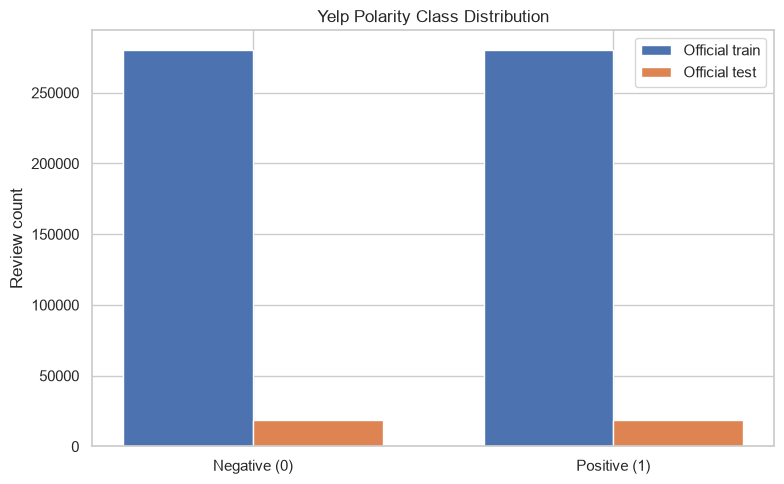

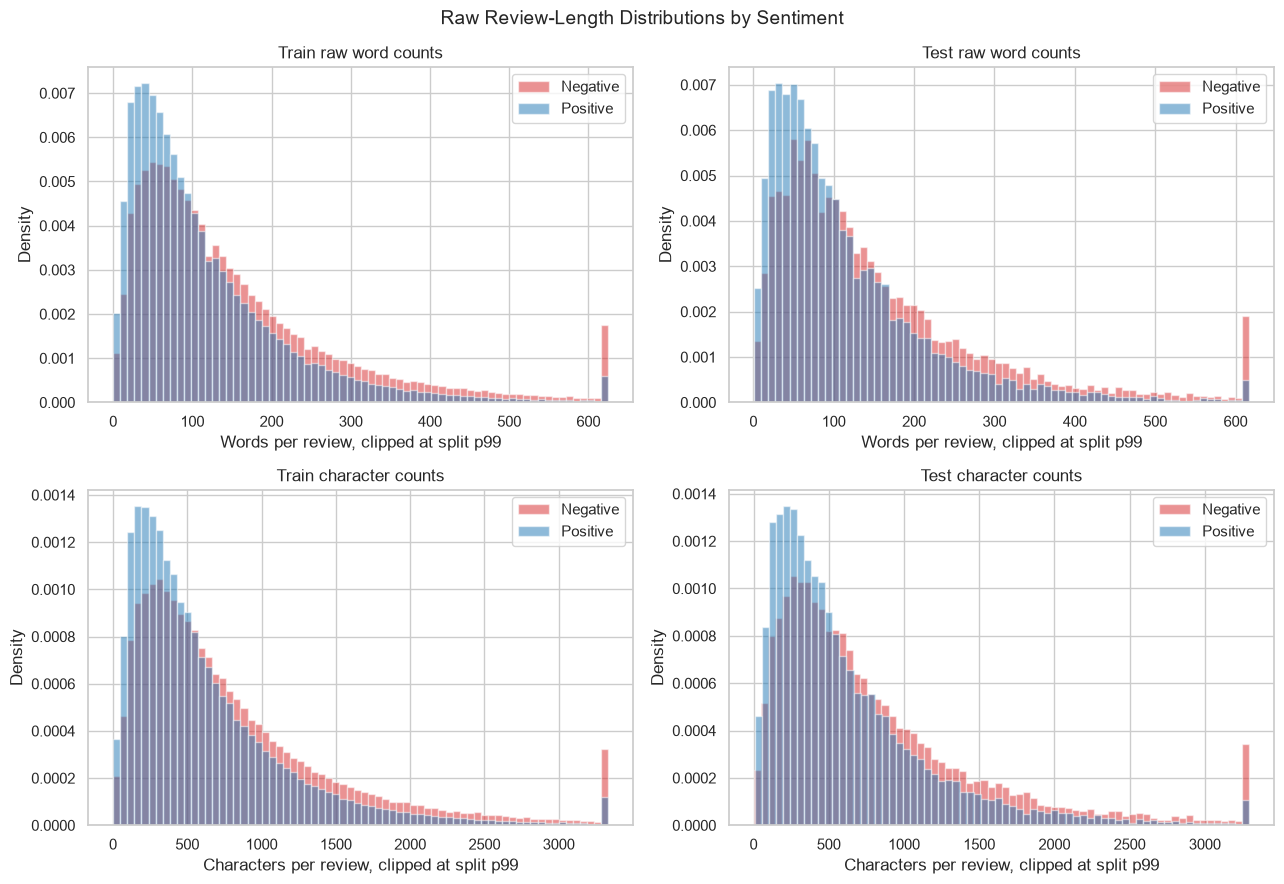

Raw analysis: outputs/metrics/raw_data_analysis.json
Class plot: outputs/plots/raw_class_distribution.png
Length plot: outputs/plots/raw_review_length_distribution.png
PHASE A ARTIFACTS WRITTEN


In [5]:
class_plot_path = (
    plots_directory
    / "raw_class_distribution.png"
)
length_plot_path = (
    plots_directory
    / "raw_review_length_distribution.png"
)

class_figure, class_axis = plt.subplots(
    figsize=(8, 5)
)

class_positions = np.arange(2)
bar_width = 0.36

train_class_counts = [
    raw_split_summaries["train"][
        "class_counts"
    ]["negative_label_0"],
    raw_split_summaries["train"][
        "class_counts"
    ]["positive_label_1"],
]
test_class_counts = [
    raw_split_summaries["test"][
        "class_counts"
    ]["negative_label_0"],
    raw_split_summaries["test"][
        "class_counts"
    ]["positive_label_1"],
]

class_axis.bar(
    class_positions - bar_width / 2,
    train_class_counts,
    width=bar_width,
    label="Official train",
)
class_axis.bar(
    class_positions + bar_width / 2,
    test_class_counts,
    width=bar_width,
    label="Official test",
)
class_axis.set_xticks(
    class_positions,
    ["Negative (0)", "Positive (1)"],
)
class_axis.set_ylabel("Review count")
class_axis.set_title(
    "Yelp Polarity Class Distribution"
)
class_axis.legend()
class_figure.tight_layout()
class_figure.savefig(
    class_plot_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

length_figure, length_axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
)

for column_index, split_name in enumerate(
    ["train", "test"]
):
    labels = raw_split_arrays[split_name][
        "labels"
    ]
    word_lengths = raw_split_arrays[split_name][
        "word_lengths"
    ]
    character_lengths = raw_split_arrays[
        split_name
    ]["character_lengths"]

    word_clip = float(
        np.quantile(word_lengths, 0.99)
    )
    character_clip = float(
        np.quantile(character_lengths, 0.99)
    )

    for label, class_name, color in [
        (0, "Negative", "tab:red"),
        (1, "Positive", "tab:blue"),
    ]:
        label_mask = labels == label

        length_axes[0, column_index].hist(
            np.clip(
                word_lengths[label_mask],
                0,
                word_clip,
            ),
            bins=70,
            alpha=0.50,
            density=True,
            label=class_name,
            color=color,
        )

        length_axes[1, column_index].hist(
            np.clip(
                character_lengths[label_mask],
                0,
                character_clip,
            ),
            bins=70,
            alpha=0.50,
            density=True,
            label=class_name,
            color=color,
        )

    length_axes[0, column_index].set_title(
        f"{split_name.title()} raw word counts"
    )
    length_axes[0, column_index].set_xlabel(
        "Words per review, clipped at split p99"
    )
    length_axes[0, column_index].set_ylabel(
        "Density"
    )
    length_axes[0, column_index].legend()

    length_axes[1, column_index].set_title(
        f"{split_name.title()} character counts"
    )
    length_axes[1, column_index].set_xlabel(
        "Characters per review, clipped at split p99"
    )
    length_axes[1, column_index].set_ylabel(
        "Density"
    )
    length_axes[1, column_index].legend()

length_figure.suptitle(
    "Raw Review-Length Distributions by Sentiment",
    fontsize=14,
)
length_figure.tight_layout()
length_figure.savefig(
    length_plot_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

raw_analysis_path = (
    metrics_directory
    / "raw_data_analysis.json"
)

raw_analysis_path.write_text(
    json.dumps(
        raw_analysis,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
    newline="\n",
)

print(
    "Raw analysis:",
    "outputs/metrics/raw_data_analysis.json",
)
print(
    "Class plot:",
    "outputs/plots/raw_class_distribution.png",
)
print(
    "Length plot:",
    (
        "outputs/plots/"
        "raw_review_length_distribution.png"
    ),
)
print("PHASE A ARTIFACTS WRITTEN")


## Next phase

After the raw-data audit is verified, this notebook will be extended with:

1. deterministic stratified training and validation splits;
2. sentiment-aware normalization;
3. stopword removal with negation preservation;
4. Porter stemming;
5. training-only vocabulary construction;
6. fixed-length integer encoding;
7. processed-data integrity checks and manifests.


## Phase B - Deterministic preprocessing and artifact construction

The raw-data audit above is now treated as verified evidence.

This phase will:

1. create a deterministic stratified train/validation split from the official training split;
2. display representative raw training examples without using the official test set for model-selection decisions;
3. normalize HTML entities, tags, whitespace, case, negation contractions, punctuation, and special characters;
4. remove English stopwords while preserving `no`, `nor`, `not`, and `never`;
5. apply deterministic Porter stemming;
6. construct the vocabulary from the training subset only;
7. quantify processed sequence lengths using the training subset only;
8. encode train, validation, and test reviews using the locked training vocabulary;
9. map reviews that become token-empty after preprocessing to one `<UNK>` token;
10. save processed arrays plus split, vocabulary, preprocessing, and integrity manifests.

The official test labels are not used for vocabulary construction, sequence-length decisions, threshold selection, hyperparameter selection, or model selection.

In [6]:
import html
import unicodedata
from collections import Counter
from functools import lru_cache

from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import (
    ENGLISH_STOP_WORDS,
)
from sklearn.model_selection import train_test_split


processed_directory = (
    repo_root
    / data_config["processed_dir"]
)

processed_directory.mkdir(
    parents=True,
    exist_ok=True,
)


vocabulary_path = (
    repo_root
    / data_config["vocabulary_file"]
)

split_manifest_path = (
    repo_root
    / data_config["split_manifest_file"]
)

preprocessing_summary_path = (
    metrics_directory
    / "preprocessing_summary.json"
)


split_seed = int(
    data_config["split_seed"]
)

validation_fraction = float(
    data_config["validation_fraction"]
)

maximum_vocabulary_size = int(
    data_config["vocabulary_size"]
)

minimum_token_frequency = int(
    data_config["minimum_token_frequency"]
)

sequence_length = int(
    data_config["sequence_length"]
)

pad_token = data_config["pad_token"]
unknown_token = data_config["unknown_token"]

pad_index = int(
    data_config["pad_index"]
)

unknown_index = int(
    data_config["unknown_index"]
)


assert pad_index == 0
assert unknown_index == 1
assert maximum_vocabulary_size >= 2
assert sequence_length > 0
assert 0.0 < validation_fraction < 1.0


print(
    "Processed directory:",
    "task2_sentiment/data/processed/Anshika_Goel",
)
print(
    "Vocabulary artifact:",
    "outputs/metrics/vocabulary.json",
)
print(
    "Split manifest:",
    "outputs/metrics/split_manifest.json",
)
print("PHASE B CONFIGURATION VERIFIED")

Processed directory: task2_sentiment/data/processed/Anshika_Goel
Vocabulary artifact: outputs/metrics/vocabulary.json
Split manifest: outputs/metrics/split_manifest.json
PHASE B CONFIGURATION VERIFIED


In [7]:
official_train_labels = np.asarray(
    dataset["train"]["label"],
    dtype=np.int8,
)

official_train_indices = np.arange(
    len(dataset["train"]),
    dtype=np.int32,
)


train_indices, validation_indices = (
    train_test_split(
        official_train_indices,
        test_size=validation_fraction,
        random_state=split_seed,
        shuffle=True,
        stratify=official_train_labels,
    )
)


train_indices = np.sort(
    np.asarray(
        train_indices,
        dtype=np.int32,
    )
)

validation_indices = np.sort(
    np.asarray(
        validation_indices,
        dtype=np.int32,
    )
)


assert train_indices.size == 504_000
assert validation_indices.size == 56_000

assert np.intersect1d(
    train_indices,
    validation_indices,
).size == 0

assert (
    train_indices.size
    + validation_indices.size
    == len(dataset["train"])
)


train_labels = official_train_labels[
    train_indices
]

validation_labels = official_train_labels[
    validation_indices
]


split_class_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "examples": int(
                train_indices.size
            ),
            "negative": int(
                np.count_nonzero(
                    train_labels == 0
                )
            ),
            "positive": int(
                np.count_nonzero(
                    train_labels == 1
                )
            ),
        },
        {
            "split": "validation",
            "examples": int(
                validation_indices.size
            ),
            "negative": int(
                np.count_nonzero(
                    validation_labels == 0
                )
            ),
            "positive": int(
                np.count_nonzero(
                    validation_labels == 1
                )
            ),
        },
        {
            "split": "official_test",
            "examples": int(
                len(dataset["test"])
            ),
            "negative": int(
                np.count_nonzero(
                    np.asarray(
                        dataset["test"]["label"]
                    ) == 0
                )
            ),
            "positive": int(
                np.count_nonzero(
                    np.asarray(
                        dataset["test"]["label"]
                    ) == 1
                )
            ),
        },
    ]
)

display(split_class_summary)


representative_rows = []

for sentiment_label, sentiment_name in [
    (0, "negative"),
    (1, "positive"),
]:
    matching_indices = train_indices[
        train_labels == sentiment_label
    ]

    for source_index in matching_indices[:2]:
        raw_text = dataset["train"][
            int(source_index)
        ]["text"]

        representative_rows.append(
            {
                "source_index": int(
                    source_index
                ),
                "sentiment": sentiment_name,
                "raw_character_count": len(
                    raw_text
                ),
                "raw_preview": (
                    raw_text[:500]
                ),
            }
        )


representative_examples = pd.DataFrame(
    representative_rows
)

display(representative_examples)

print(
    "DETERMINISTIC STRATIFIED "
    "TRAIN/VALIDATION SPLIT CREATED"
)

,split,examples,negative,positive
0,train,504000,252000,252000
1,validation,56000,28000,28000
2,official_test,38000,19000,19000


,source_index,sentiment,raw_character_count,raw_preview
0,0,negative,643,"Unfortunately, the frustration of being Dr. Go..."
1,3,negative,1050,I'm writing this review to give you a heads up...
2,1,positive,495,Been going to Dr. Goldberg for over 10 years. ...
3,4,positive,429,All the food is great here. But the best thing...


DETERMINISTIC STRATIFIED TRAIN/VALIDATION SPLIT CREATED


In [8]:
preserved_negations = {
    str(token).lower()
    for token
    in preprocessing_config[
        "preserved_negations"
    ]
}

expected_negations = {
    "no",
    "nor",
    "not",
    "never",
}

assert (
    preserved_negations
    == expected_negations
)


stopwords = (
    set(ENGLISH_STOP_WORDS)
    - preserved_negations
)


porter_stemmer = PorterStemmer()


html_tag_pattern = re.compile(
    r"<[^>]+>"
)

whitespace_pattern = re.compile(
    r"\s+"
)

special_character_pattern = re.compile(
    r"[^a-z0-9\s']+"
)

apostrophe_pattern = re.compile(
    r"'+"
)

token_pattern = re.compile(
    r"[a-z0-9]+"
)


special_negation_contractions = {
    "can't": "can not",
    "cannot": "can not",
    "won't": "will not",
    "shan't": "shall not",
    "ain't": "is not",
}


@lru_cache(maxsize=250_000)
def stem_token(
    token: str,
) -> str:
    return porter_stemmer.stem(token)


def normalize_text(
    text: str,
) -> str:
    if text is None:
        text = ""
    elif not isinstance(text, str):
        text = str(text)

    text = html.unescape(text)

    text = unicodedata.normalize(
        "NFKC",
        text,
    )

    text = text.replace(
        "\u2019",
        "'",
    )

    text = text.replace(
        "\u2018",
        "'",
    )

    text = text.lower()

    text = html_tag_pattern.sub(
        " ",
        text,
    )

    for contraction, replacement in (
        special_negation_contractions.items()
    ):
        text = re.sub(
            rf"\b{re.escape(contraction)}\b",
            replacement,
            text,
        )

    text = re.sub(
        r"n['']t\b",
        " not",
        text,
    )

    text = special_character_pattern.sub(
        " ",
        text,
    )

    text = apostrophe_pattern.sub(
        " ",
        text,
    )

    text = whitespace_pattern.sub(
        " ",
        text,
    ).strip()

    return text


def preprocess_text(
    text: str,
) -> list[str]:
    normalized_text = normalize_text(text)

    raw_tokens = token_pattern.findall(
        normalized_text
    )

    filtered_tokens = [
        token
        for token in raw_tokens
        if (
            token not in stopwords
            or token in preserved_negations
        )
    ]

    stemmed_tokens = [
        stem_token(token)
        for token in filtered_tokens
    ]

    return stemmed_tokens


preprocessing_demo_rows = []

for row in representative_rows:
    source_index = row["source_index"]

    original_text = dataset["train"][
        source_index
    ]["text"]

    processed_tokens = preprocess_text(
        original_text
    )

    preprocessing_demo_rows.append(
        {
            "source_index": source_index,
            "sentiment": row["sentiment"],
            "raw_preview": (
                original_text[:220]
            ),
            "processed_preview": " ".join(
                processed_tokens[:45]
            ),
            "processed_token_count": len(
                processed_tokens
            ),
        }
    )


display(
    pd.DataFrame(
        preprocessing_demo_rows
    )
)

print(
    "PREPROCESSING FUNCTIONS DEFINED"
)

,source_index,sentiment,raw_preview,processed_preview,processed_token_count
0,0,negative,"Unfortunately, the frustration of being Dr. Go...",unfortun frustrat dr goldberg s patient repeat...,55
1,3,negative,I'm writing this review to give you a heads up...,m write review head doctor offic staff adminis...,91
2,1,positive,Been going to Dr. Goldberg for over 10 years. ...,go dr goldberg 10 year think 1st patient start...,39
3,4,positive,All the food is great here. But the best thing...,food great best thing wing wing simpli fantast...,43


PREPROCESSING FUNCTIONS DEFINED


In [9]:
training_token_counter = Counter()

training_processed_lengths = np.empty(
    train_indices.size,
    dtype=np.int32,
)

training_empty_after_preprocessing = 0


for row_index, source_index in enumerate(
    tqdm(
        train_indices,
        total=train_indices.size,
        desc=(
            "Building training-only "
            "vocabulary statistics"
        ),
    )
):
    tokens = preprocess_text(
        dataset["train"][
            int(source_index)
        ]["text"]
    )

    training_processed_lengths[
        row_index
    ] = len(tokens)

    if len(tokens) == 0:
        training_empty_after_preprocessing += 1

    training_token_counter.update(tokens)


eligible_vocabulary_tokens = [
    (
        token,
        frequency,
    )
    for token, frequency
    in training_token_counter.items()
    if frequency >= minimum_token_frequency
]


eligible_vocabulary_tokens.sort(
    key=lambda item: (
        -item[1],
        item[0],
    )
)


maximum_learned_tokens = (
    maximum_vocabulary_size - 2
)

selected_vocabulary_tokens = (
    eligible_vocabulary_tokens[
        :maximum_learned_tokens
    ]
)


vocabulary = {
    pad_token: pad_index,
    unknown_token: unknown_index,
}


for vocabulary_index, (
    token,
    _frequency,
) in enumerate(
    selected_vocabulary_tokens,
    start=2,
):
    vocabulary[token] = (
        vocabulary_index
    )


assert vocabulary[pad_token] == 0
assert vocabulary[unknown_token] == 1
assert len(vocabulary) <= (
    maximum_vocabulary_size
)


training_processed_length_summary = (
    describe_values(
        training_processed_lengths
    )
)

training_truncation_count = int(
    np.count_nonzero(
        training_processed_lengths
        > sequence_length
    )
)

training_truncation_fraction = float(
    training_truncation_count
    / train_indices.size
)


vocabulary_metadata = {
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "constructed_from": (
        "training subset only"
    ),
    "training_examples": int(
        train_indices.size
    ),
    "configured_maximum_vocabulary_size": (
        maximum_vocabulary_size
    ),
    "minimum_token_frequency": (
        minimum_token_frequency
    ),
    "observed_unique_processed_tokens": int(
        len(training_token_counter)
    ),
    "eligible_tokens_at_minimum_frequency": int(
        len(eligible_vocabulary_tokens)
    ),
    "final_vocabulary_size": int(
        len(vocabulary)
    ),
    "pad_token": pad_token,
    "pad_index": pad_index,
    "unknown_token": unknown_token,
    "unknown_index": unknown_index,
}


vocabulary_artifact = {
    "metadata": vocabulary_metadata,
    "token_to_index": vocabulary,
}


vocabulary_path.write_text(
    json.dumps(
        vocabulary_artifact,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
    newline="\n",
)


length_decision_table = pd.DataFrame(
    [
        {
            "training_examples": int(
                train_indices.size
            ),
            "median_processed_tokens": (
                training_processed_length_summary[
                    "median"
                ]
            ),
            "p90_processed_tokens": (
                training_processed_length_summary[
                    "p90"
                ]
            ),
            "p95_processed_tokens": (
                training_processed_length_summary[
                    "p95"
                ]
            ),
            "p99_processed_tokens": (
                training_processed_length_summary[
                    "p99"
                ]
            ),
            "configured_sequence_length": (
                sequence_length
            ),
            "reviews_truncated": (
                training_truncation_count
            ),
            "truncation_fraction": (
                training_truncation_fraction
            ),
            "empty_after_preprocessing": (
                training_empty_after_preprocessing
            ),
            "final_vocabulary_size": (
                len(vocabulary)
            ),
        }
    ]
)

display(length_decision_table)

print(
    "TRAINING-ONLY VOCABULARY CONSTRUCTED"
)

Building training-only vocabulary statistics:   0%|          | 0/504000 [00:00<?, ?it/s]

Building training-only vocabulary statistics:   0%|          | 365/504000 [00:00<02:18, 3632.37it/s]

Building training-only vocabulary statistics:   0%|          | 786/504000 [00:00<02:07, 3960.15it/s]

Building training-only vocabulary statistics:   0%|          | 1345/504000 [00:00<01:47, 4686.36it/s]

Building training-only vocabulary statistics:   0%|          | 1877/504000 [00:00<01:42, 4917.24it/s]

...

Building training-only vocabulary statistics: 100%|█████████▉| 502707/504000 [01:19<00:00, 6578.56it/s]

Building training-only vocabulary statistics: 100%|█████████▉| 503366/504000 [01:20<00:00, 6543.07it/s]

Building training-only vocabulary statistics: 100%|██████████| 504000/504000 [01:20<00:00, 6284.34it/s]

,training_examples,median_processed_tokens,p90_processed_tokens,p95_processed_tokens,p99_processed_tokens,configured_sequence_length,reviews_truncated,truncation_fraction,empty_after_preprocessing,final_vocabulary_size
0,504000,48.0,140.0,185.0,302.0,256,8983,0.017823,37,50000


TRAINING-ONLY VOCABULARY CONSTRUCTED


In [10]:
def encode_split_to_disk(
    *,
    split_name: str,
    source_dataset,
    source_indices: np.ndarray,
) -> dict:
    input_path = (
        processed_directory
        / f"{split_name}_input_ids.npy"
    )

    label_path = (
        processed_directory
        / f"{split_name}_labels.npy"
    )

    source_index_path = (
        processed_directory
        / f"{split_name}_source_indices.npy"
    )

    encoded_inputs = np.lib.format.open_memmap(
        input_path,
        mode="w+",
        dtype=np.int32,
        shape=(
            source_indices.size,
            sequence_length,
        ),
    )

    encoded_labels = np.empty(
        source_indices.size,
        dtype=np.int8,
    )

    total_processed_tokens = 0
    total_oov_tokens = 0
    truncated_reviews = 0
    empty_reviews = 0


    for row_index, source_index in enumerate(
        tqdm(
            source_indices,
            total=source_indices.size,
            desc=f"Encoding {split_name}",
        )
    ):
        record = source_dataset[
            int(source_index)
        ]

        tokens = preprocess_text(
            record["text"]
        )

        total_processed_tokens += len(tokens)

        if len(tokens) == 0:
            empty_reviews += 1
            token_ids = [
                unknown_index
            ]
        else:
            token_ids = [
                vocabulary.get(
                    token,
                    unknown_index,
                )
                for token in tokens
            ]

            total_oov_tokens += sum(
                token_id
                == unknown_index
                for token_id
                in token_ids
            )

        if len(token_ids) > sequence_length:
            truncated_reviews += 1

        token_ids = token_ids[
            :sequence_length
        ]

        encoded_inputs[
            row_index
        ].fill(
            pad_index
        )

        encoded_inputs[
            row_index,
            :len(token_ids),
        ] = np.asarray(
            token_ids,
            dtype=np.int32,
        )

        encoded_labels[
            row_index
        ] = int(
            record["label"]
        )


    encoded_inputs.flush()

    np.save(
        label_path,
        encoded_labels,
        allow_pickle=False,
    )

    np.save(
        source_index_path,
        np.asarray(
            source_indices,
            dtype=np.int32,
        ),
        allow_pickle=False,
    )


    return {
        "split": split_name,
        "examples": int(
            source_indices.size
        ),
        "input_ids_file": (
            input_path.name
        ),
        "labels_file": (
            label_path.name
        ),
        "source_indices_file": (
            source_index_path.name
        ),
        "shape": [
            int(source_indices.size),
            int(sequence_length),
        ],
        "dtype": "int32",
        "negative_examples": int(
            np.count_nonzero(
                encoded_labels == 0
            )
        ),
        "positive_examples": int(
            np.count_nonzero(
                encoded_labels == 1
            )
        ),
        "empty_after_preprocessing": int(
            empty_reviews
        ),
        "truncated_reviews": int(
            truncated_reviews
        ),
        "processed_tokens_before_truncation": int(
            total_processed_tokens
        ),
        "oov_tokens_before_truncation": int(
            total_oov_tokens
        ),
        "oov_fraction_before_truncation": (
            float(
                total_oov_tokens
                / total_processed_tokens
            )
            if total_processed_tokens
            else 0.0
        ),
    }


test_indices = np.arange(
    len(dataset["test"]),
    dtype=np.int32,
)


processed_split_summaries = {}


processed_split_summaries["train"] = (
    encode_split_to_disk(
        split_name="train",
        source_dataset=dataset["train"],
        source_indices=train_indices,
    )
)


processed_split_summaries["validation"] = (
    encode_split_to_disk(
        split_name="validation",
        source_dataset=dataset["train"],
        source_indices=validation_indices,
    )
)


processed_split_summaries["test"] = (
    encode_split_to_disk(
        split_name="test",
        source_dataset=dataset["test"],
        source_indices=test_indices,
    )
)


display(
    pd.DataFrame(
        processed_split_summaries.values()
    )
)

print(
    "TRAIN / VALIDATION / TEST "
    "ENCODING COMPLETED"
)

Encoding train:   0%|          | 0/504000 [00:00<?, ?it/s]

Encoding train:   0%|          | 578/504000 [00:00<01:27, 5778.74it/s]

Encoding train:   0%|          | 1182/504000 [00:00<01:25, 5908.19it/s]

Encoding train:   0%|          | 1797/504000 [00:00<01:23, 5994.75it/s]

Encoding train:   0%|          | 2397/504000 [00:00<01:24, 5966.32it/s]

...

Encoding test:  99%|█████████▉| 37722/38000 [00:19<00:00, 1904.87it/s]

Encoding test: 100%|█████████▉| 37913/38000 [00:19<00:00, 1857.22it/s]

Encoding test: 100%|██████████| 38000/38000 [00:19<00:00, 1928.63it/s]

,split,examples,input_ids_file,labels_file,source_indices_file,shape,dtype,negative_examples,positive_examples,empty_after_preprocessing,truncated_reviews,processed_tokens_before_truncation,oov_tokens_before_truncation,oov_fraction_before_truncation
0,train,504000,train_input_ids.npy,train_labels.npy,train_source_indices.npy,"[504000, 256]",int32,252000,252000,37,8983,33340704,152984,0.004589
1,validation,56000,validation_input_ids.npy,validation_labels.npy,validation_source_indices.npy,"[56000, 256]",int32,28000,28000,3,949,3675745,20816,0.005663
2,test,38000,test_input_ids.npy,test_labels.npy,test_source_indices.npy,"[38000, 256]",int32,19000,19000,1,651,2500269,13588,0.005435


TRAIN / VALIDATION / TEST ENCODING COMPLETED


In [11]:
def sha256_array(
    values: np.ndarray,
) -> str:
    contiguous_values = np.ascontiguousarray(
        values
    )

    return hashlib.sha256(
        contiguous_values.tobytes(
            order="C"
        )
    ).hexdigest()


def sha256_file(
    path: Path,
) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as handle:
        while True:
            block = handle.read(
                1024 * 1024
            )

            if not block:
                break

            digest.update(block)

    return digest.hexdigest()


split_manifest = {
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "dataset": data_config[
        "dataset_name"
    ],
    "dataset_revision": data_config[
        "dataset_revision"
    ],
    "official_training_examples": int(
        len(dataset["train"])
    ),
    "official_test_examples": int(
        len(dataset["test"])
    ),
    "split_seed": split_seed,
    "validation_fraction": (
        validation_fraction
    ),
    "training_examples": int(
        train_indices.size
    ),
    "validation_examples": int(
        validation_indices.size
    ),
    "training_index_sha256": (
        sha256_array(
            train_indices
        )
    ),
    "validation_index_sha256": (
        sha256_array(
            validation_indices
        )
    ),
    "training_class_counts": {
        "negative": int(
            np.count_nonzero(
                train_labels == 0
            )
        ),
        "positive": int(
            np.count_nonzero(
                train_labels == 1
            )
        ),
    },
    "validation_class_counts": {
        "negative": int(
            np.count_nonzero(
                validation_labels == 0
            )
        ),
        "positive": int(
            np.count_nonzero(
                validation_labels == 1
            )
        ),
    },
    "train_validation_overlap": int(
        np.intersect1d(
            train_indices,
            validation_indices,
        ).size
    ),
    "official_test_policy": (
        "Official test rows were not used "
        "for vocabulary construction, "
        "sequence-length analysis, "
        "hyperparameter selection, "
        "threshold selection, or "
        "model selection."
    ),
}


split_manifest_path.write_text(
    json.dumps(
        split_manifest,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
    newline="\n",
)


preprocessing_summary = {
    "created_utc": datetime.now(
        timezone.utc
    ).isoformat(),
    "lowercase": bool(
        preprocessing_config[
            "lowercase"
        ]
    ),
    "normalize_html": bool(
        preprocessing_config[
            "normalize_html"
        ]
    ),
    "normalize_whitespace": bool(
        preprocessing_config[
            "normalize_whitespace"
        ]
    ),
    "expand_negation_contractions": bool(
        preprocessing_config[
            "expand_negation_contractions"
        ]
    ),
    "remove_punctuation": bool(
        preprocessing_config[
            "remove_punctuation"
        ]
    ),
    "remove_special_characters": bool(
        preprocessing_config[
            "remove_special_characters"
        ]
    ),
    "remove_stopwords": bool(
        preprocessing_config[
            "remove_stopwords"
        ]
    ),
    "stopword_source": (
        "sklearn.feature_extraction.text."
        "ENGLISH_STOP_WORDS"
    ),
    "preserved_negations": sorted(
        preserved_negations
    ),
    "stemming": "PorterStemmer",
    "tokenization": (
        "regex lowercase alphanumeric tokens"
    ),
    "empty_review_policy": (
        "If preprocessing produces zero tokens, "
        "encode one UNK token followed by PAD."
    ),
    "vocabulary_source": (
        "training subset only"
    ),
    "vocabulary_size": int(
        len(vocabulary)
    ),
    "minimum_token_frequency": (
        minimum_token_frequency
    ),
    "sequence_length": (
        sequence_length
    ),
    "training_processed_length": (
        training_processed_length_summary
    ),
    "training_reviews_longer_than_sequence": (
        training_truncation_count
    ),
    "training_truncation_fraction": (
        training_truncation_fraction
    ),
    "training_empty_after_preprocessing": (
        training_empty_after_preprocessing
    ),
    "processed_splits": (
        processed_split_summaries
    ),
    "vocabulary_file_sha256": (
        sha256_file(
            vocabulary_path
        )
    ),
}


preprocessing_summary_path.write_text(
    json.dumps(
        preprocessing_summary,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
    newline="\n",
)


required_processed_files = [
    "train_input_ids.npy",
    "train_labels.npy",
    "train_source_indices.npy",
    "validation_input_ids.npy",
    "validation_labels.npy",
    "validation_source_indices.npy",
    "test_input_ids.npy",
    "test_labels.npy",
    "test_source_indices.npy",
]


for file_name in required_processed_files:
    file_path = (
        processed_directory
        / file_name
    )

    assert file_path.is_file(), (
        f"Missing processed file: "
        f"{file_name}"
    )


assert split_manifest[
    "train_validation_overlap"
] == 0

assert (
    processed_split_summaries[
        "train"
    ]["examples"]
    == 504_000
)

assert (
    processed_split_summaries[
        "validation"
    ]["examples"]
    == 56_000
)

assert (
    processed_split_summaries[
        "test"
    ]["examples"]
    == 38_000
)


print(
    "Split manifest:",
    "outputs/metrics/split_manifest.json",
)
print(
    "Vocabulary:",
    "outputs/metrics/vocabulary.json",
)
print(
    "Preprocessing summary:",
    "outputs/metrics/preprocessing_summary.json",
)
print(
    "Processed arrays:",
    "task2_sentiment/data/processed/Anshika_Goel/",
)
print(
    "PHASE B ARTIFACTS AND "
    "INTEGRITY CHECKS COMPLETED"
)

Split manifest: outputs/metrics/split_manifest.json
Vocabulary: outputs/metrics/vocabulary.json
Preprocessing summary: outputs/metrics/preprocessing_summary.json
Processed arrays: task2_sentiment/data/processed/Anshika_Goel/
PHASE B ARTIFACTS AND INTEGRITY CHECKS COMPLETED


## Phase B completion criteria

Phase B is complete only if all appended code cells execute without errors and produce:

- a 504,000-example training subset;
- a 56,000-example validation subset;
- zero train/validation index overlap;
- a vocabulary constructed only from the training subset;
- training-only processed-length and truncation statistics;
- fixed-length integer arrays with sequence length 256;
- `<PAD>` index 0 and `<UNK>` index 1;
- deterministic handling of reviews that become empty after preprocessing;
- `split_manifest.json`;
- `vocabulary.json`;
- `preprocessing_summary.json`;
- ignored processed NumPy arrays for train, validation, and test.

No model training occurs in this notebook.